In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


#  RNN, LSTM and GRU

In class we have seen what are Recurrent Neural Networks, Long Short-Term Memory (LSTM) Networks and Gated Recurrent Unit (GRU).

Here we will showcase how they can be used for regression and forecasting the next sequence of values of a sequence synthethically created, a many to one prediction problem.
The problem can be summarise to the following: based on a sequence of data points of *seq_length* size, predict the next data point. The sequence of points can be seen as stock values, so the order matters. Imagine we have assess to past data points and we want to predict the next data points.

In [3]:
# Generating synthetic sine wave data + random values from a normal distribution
points = 800
t = np.linspace(0, 799, points)

noise_mean = 0 # to add some normal random noise (mean, std)
noise_std = 0.01
# based on sine wave
data = np.sin(0.02 * t) + np.random.normal(noise_mean, noise_std, points)

# Function to create sequences
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data)-seq_length-1):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length]
        xs.append(x) # based on a seq_length window
        ys.append(y) # going to predict the next point
    return np.array(xs), np.array(ys)

seq_length = 40 # 
X, y = create_sequences(data, seq_length)
print("sequence of points available to learn: ", X.shape)
print("points to predict",y.shape)

sequence of points available to learn:  (759, 40)
points to predict (759,)


Since the order matters the split will preserve the order of the sequence. 80% as suggested means that from the start to 80% of the next sequence data points will be used to Train, and the next 20% are used to test.

In [4]:
# Split into train and test sets
the_split = 0.8 # 80% of the data
train_size = int(len(X) * the_split)
test_size = len(X) - train_size

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert to tensors
X_train = torch.FloatTensor(X_train).view(-1, seq_length, 1)
y_train = torch.FloatTensor(y_train).view(-1, 1)
X_test = torch.FloatTensor(X_test).view(-1, seq_length, 1)
y_test = torch.FloatTensor(y_test).view(-1, 1)


Let us visualize the train and test.

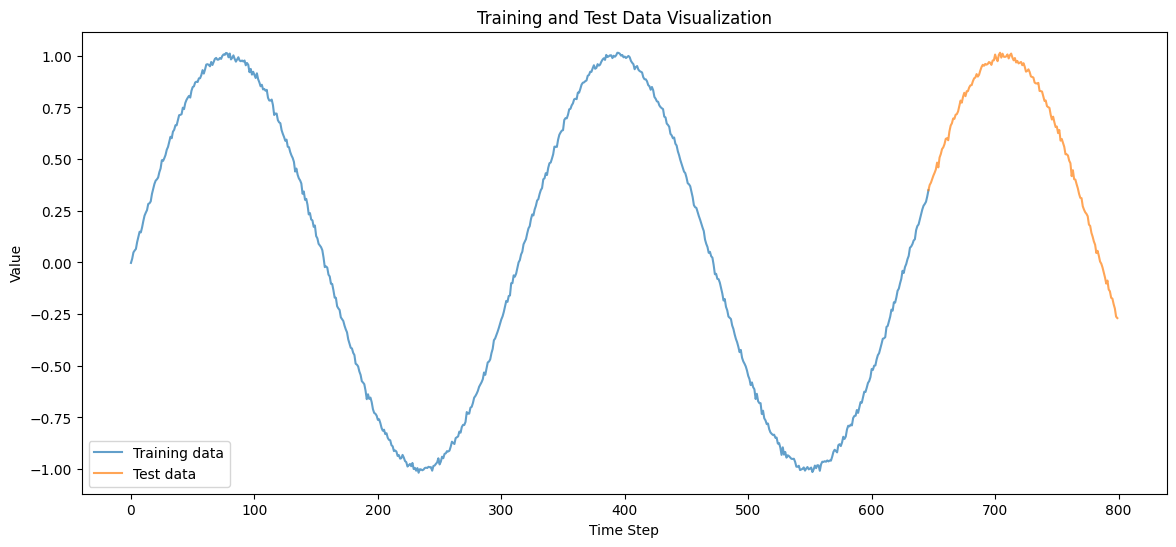

In [5]:
plt.figure(figsize=(14, 6))

# Highlight the training data
train_t = t[:train_size + seq_length]
plt.plot(train_t, data[:train_size + seq_length], label='Training data', alpha=0.7)

# Highlight the test data
test_t = t[train_size + seq_length - 1:]  # Starting from the end of the training data
plt.plot(test_t, data[train_size + seq_length - 1:], label='Test data', alpha=0.7)

plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('Training and Test Data Visualization')
plt.legend()
plt.show()


## Exercise 1 - Analyse the following code for a generic Sequence Model for RNN with one hidden layer. Check the documentation on LSTM and GRU on torch and complete the code.

https://pytorch.org/docs/stable/nn.html#recurrent-layers


In [ ]:
class SequenceModel(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=100, output_size=1, model_type=""):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        
        if model_type == "LSTM":
            # TODO your code here
            self.lstm = nn.LSTM(input_size, hidden_layer_size)
        elif model_type == "GRU":
            # TODO your code here
            self.gru = nn.GRU(input_size, hidden_layer_size) 
        else:  
            self.rnn = nn.RNN(input_size, hidden_layer_size)
        
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        
        rnn_out, _ = self.rnn(input_seq)
        
        predictions = self.linear(rnn_out.view(len(input_seq), -1))
        return predictions[-1]


## Exercise 2 - Analyse the following code. Create an RNN, LSTM and GRU neural network and compare the results.

In [7]:
def train_rnn(model, epochs, optimizer, loss_function):
    for i in range(epochs):
        # do an epoch
        for seq, labels in zip(X_train, y_train):
            optimizer.zero_grad()
            
            # remember to reset the state
            model.hidden_cell = (torch.zeros(1, 1, model.hidden_layer_size),
                                torch.zeros(1, 1, model.hidden_layer_size))

            y_pred = model(seq)

            single_loss = loss_function(y_pred, labels)
            single_loss.backward()
            optimizer.step()

        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')
    return model

# evaluation
def evaluation(model):
    model.eval() # change to testing mode
    with torch.no_grad():
        predictions = []
        for seq in X_test:
            # reset hidden state
            model.hidden = (torch.zeros(1, 1, model.hidden_layer_size),
                            torch.zeros(1, 1, model.hidden_layer_size))
            predictions.append(model(seq).item())
    return predictions

# check results and plot
def evalresults(predictions,y_test, plot=True):
    actual = y_test.view(-1).numpy()
    predictions = np.array(predictions)

    mse = np.mean((actual - predictions)**2)
    rmse = np.sqrt(mse)

    print(f'MSE: {mse}')
    print(f'RMSE: {rmse}')
    
    if plot:
        plt.figure(figsize=(10,6))
        plt.plot(actual, label='Actual Data')
        plt.plot(predictions, label='Predicted Data')
        plt.title('Time Series Prediction')
        plt.legend()
        plt.show()

## 2.1 RNN 

In [8]:
# TODO your CODE here



## 2.2 LSTM

In [ ]:

# TODO your CODE here



## 2.3 GRU

In [10]:
# TODO your CODE here



## 3 (EXTRA) -  Explore different sequences and repeat analysis. Change the first couple of cells before exercise 1. Evaluate the impact of: 1) number of points, 2) sequence size 3) split size 4) increase/decrease noise parameters.